In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
import seaborn as sns
df = sns.load_dataset('penguins')
df.head(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [4]:
sns.set_theme(style="ticks")

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            342 non-null    object 
 1   island             342 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   species_numerical  342 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 32.1+ KB


In [5]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [6]:
df[df.duplicated(keep=False)]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex


In [7]:
df = df.dropna(subset=['bill_length_mm', 'bill_depth_mm','flipper_length_mm','body_mass_g'])
display(df.groupby('species').count())

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
species,,,,,,
Adelie,151,151,151,151,151,146
Chinstrap,68,68,68,68,68,68
Gentoo,123,123,123,123,123,119


In [8]:
map_target_class = {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}

df['species_numerical'] = df['species'].map(map_target_class)
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species_numerical
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,0


In [24]:
X = df[['bill_length_mm', 'bill_depth_mm','flipper_length_mm','body_mass_g']]
Y = df['species']

In [25]:
X_train = df.drop(['species', 'species_numerical','sex','island'], axis=1)
y_train = df['species_numerical']
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species_numerical
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,0


In [26]:
df_train, df_test = train_test_split(df, test_size=0.25, stratify=df['species'])
X_train = df_train.drop(['species', 'species_numerical','sex','island'], axis=1)
y_train = df_train['species_numerical']
X_test = df_test.drop(['species', 'species_numerical','sex','island'], axis=1)
y_test = df_test['species_numerical']

In [27]:
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [29]:
y_pred = clf.predict(X_test)

print(f"Accuracy (Precisión): {accuracy_score(y_test, y_pred):.2f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

Accuracy (Precisión): 0.92

Matriz de Confusión:
[[37  1  0]
 [ 5 12  0]
 [ 1  0 30]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91        38
           1       0.92      0.71      0.80        17
           2       1.00      0.97      0.98        31

    accuracy                           0.92        86
   macro avg       0.93      0.88      0.90        86
weighted avg       0.92      0.92      0.92        86



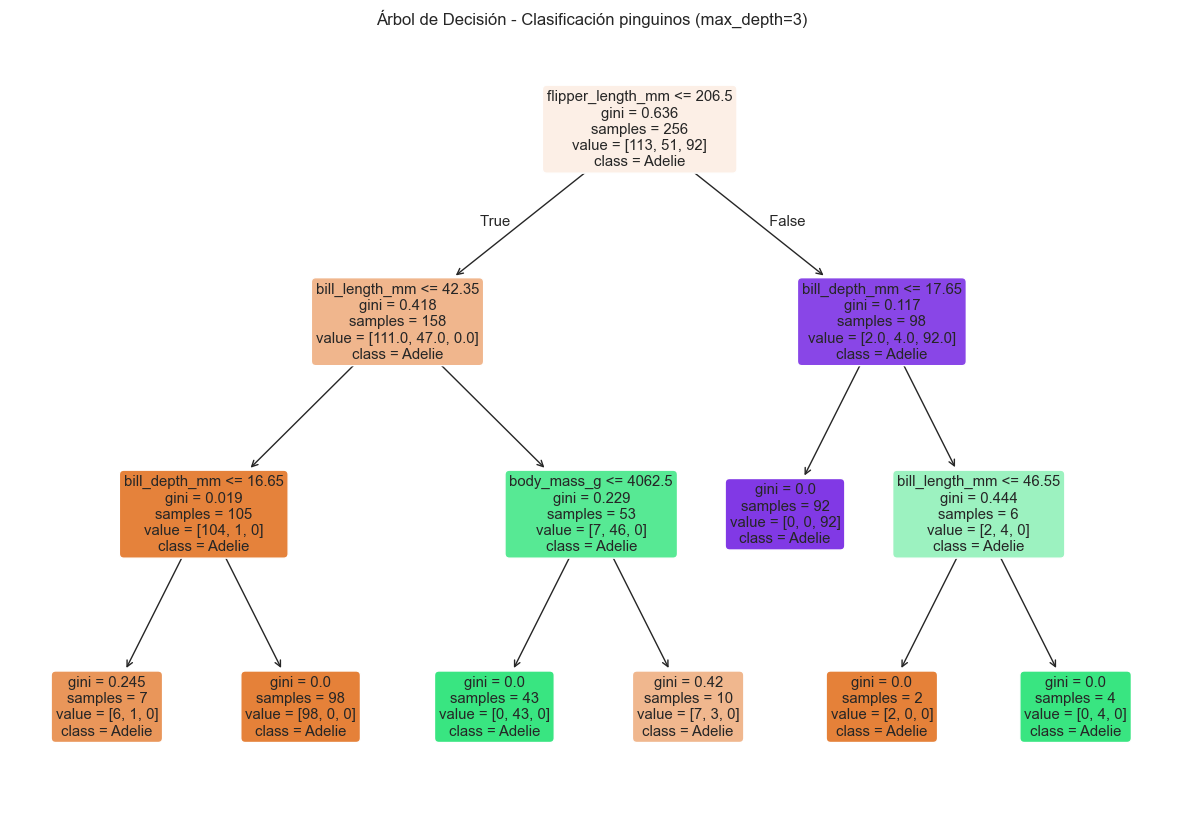

In [30]:
plt.figure(figsize=(15, 10))
plot_tree(clf,
          filled=True,      # Colorea los nodos
          rounded=True,     # Nodos con bordes redondeados
          class_names=Y, # Nombres de las clases (target)
          feature_names=X.columns) # Nombres de las características (features)
plt.title("Árbol de Decisión - Clasificación pinguinos (max_depth=3)")
plt.show()

In [35]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators=50, random_state=0, criterion='gini')
classifier.fit(X_train, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
y_pred = classifier.predict(X_test)

In [37]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
result = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(result)   
result1 = classification_report(y_test, y_pred)
print("Classification Report:")
print(result1)
result2 = accuracy_score(y_test, y_pred)
print("Accuracy:", result2)

Confusion Matrix:
[[37  1  0]
 [ 1 16  0]
 [ 0  1 30]]
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        38
           1       0.89      0.94      0.91        17
           2       1.00      0.97      0.98        31

    accuracy                           0.97        86
   macro avg       0.95      0.96      0.96        86
weighted avg       0.97      0.97      0.97        86

Accuracy: 0.9651162790697675
